# 한성대학교 공지 카테고리 분류 모델

**KLUE-RoBERTa 단일 모델 (최종)**
- title + body 통합 입력
- MAX_LEN 256 / BATCH_SIZE 16
- Cosine Annealing with Warmup
- PATIENCE 8 / label_smoothing 0.05

**카테고리 (11개)** — 기타는 학습 제외(추론 후처리로 처리함)
```
취업/채용, 학사행정, 비교과, 장학금/학자금, 봉사/서포터즈, 공모전/경진대회,
교육/특강, ROTC, 국제교류, 기숙사/생활관, 창업
```

## 0. 패키지 설치

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers datasets scikit-learn pandas numpy matplotlib seaborn torch accelerate koreanize-matplotlib -q

## 1. 데이터 로드 & 전처리

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

PATH_2025 = '/content/drive/MyDrive/2025_notice.json'
PATH_2026 = '/content/drive/MyDrive/2026.json'

CATEGORY_MAP = {
    '인턴십':        '취업/채용',
    '학자금/근로장학': '장학금/학자금',
    '장학금':        '장학금/학자금',
}
EXCLUDE_CATEGORIES = {'기타'}

def load_data(path_2025, path_2026):
    with open(path_2025, 'r', encoding='utf-8') as f:
        data_2025 = json.load(f)
    with open(path_2026, 'r', encoding='utf-8') as f:
        data_2026 = json.load(f)
    df_2025 = pd.DataFrame(data_2025)[['title', 'body', 'category']]
    df_2025['source'] = '2025'
    df_2026 = pd.DataFrame(data_2026)[['title', 'body', 'category']]
    df_2026['source'] = '2026'
    df = pd.concat([df_2025, df_2026], ignore_index=True)
    df['title'] = df['title'].astype(str).str.strip()
    df['body']  = df['body'].astype(str).str.strip().replace('nan', '')
    df = df[df['title'] != ''].reset_index(drop=True)
    df['category'] = df['category'].replace(CATEGORY_MAP)
    before = len(df)
    df = df[~df['category'].isin(EXCLUDE_CATEGORIES)].reset_index(drop=True)
    print(f'기타 제외: {before - len(df)}건')
    return df

df = load_data(PATH_2025, PATH_2026)
print(f'총 데이터: {len(df)}건')
print(df['category'].value_counts())

기타 제외: 30건
총 데이터: 1891건
category
취업/채용       628
학사행정        279
장학금/학자금     254
비교과         207
봉사/서포터즈     153
교육/특강        88
공모전/경진대회     78
ROTC         71
국제교류         56
창업           41
기숙사/생활관      36
Name: count, dtype: int64


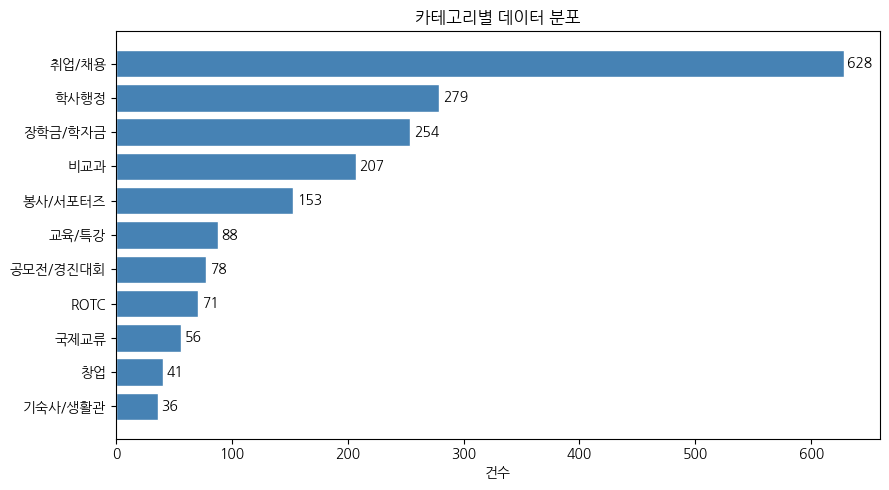


소수 클래스 (2개): {'창업': np.int64(41), '기숙사/생활관': np.int64(36)}


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
vc = df['category'].value_counts()
bars = ax.barh(vc.index, vc.values, color='steelblue', edgecolor='white')
for bar, val in zip(bars, vc.values):
    ax.text(val + 3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=10)
ax.set_xlabel('건수'); ax.set_title('카테고리별 데이터 분포'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

minority = vc[vc < 50]
if len(minority) > 0:
    print(f'\n소수 클래스 ({len(minority)}개): {dict(minority)}')

## 2. 레이블 인코딩 & 데이터 분할

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])
NUM_CLASSES  = len(le.classes_)
print(f'클래스 수: {NUM_CLASSES}')
print({i: c for i, c in enumerate(le.classes_)})

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df,   test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])
print(f'\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

클래스 수: 11
{0: 'ROTC', 1: '공모전/경진대회', 2: '교육/특강', 3: '국제교류', 4: '기숙사/생활관', 5: '봉사/서포터즈', 6: '비교과', 7: '장학금/학자금', 8: '창업', 9: '취업/채용', 10: '학사행정'}

Train: 1512 | Val: 189 | Test: 190


## 3. KLUE-RoBERTa 학습

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score, classification_report

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP    = torch.cuda.is_available()
MODEL_NAME = 'klue/roberta-base'
MAX_LEN    = 256   # 128 → 256: body 포함 문맥 확장
BATCH_SIZE = 16    # MAX_LEN 2배 → BATCH_SIZE 절반 (OOM 방지)
EPOCHS     = 20
LR         = 3e-5
PATIENCE   = 8     # val_f1 노이즈 감안, 좋은 epoch 놓치지 않도록
WARMUP_RATIO = 0.15

class_weights        = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=train_df['label'].values)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
loss_fn              = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.05)

print(f'Device: {DEVICE} | AMP: {USE_AMP}')
print(f'MAX_LEN={MAX_LEN} | BATCH_SIZE={BATCH_SIZE} | LR={LR} | PATIENCE={PATIENCE}')
print(f'Loss: CrossEntropy + label_smoothing=0.05 + class_weight')

Device: cuda | AMP: True
MAX_LEN=256 | BATCH_SIZE=16 | LR=3e-05 | PATIENCE=8
Loss: CrossEntropy + label_smoothing=0.05 + class_weight


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TitleDataset(Dataset):
    def __init__(self, titles, bodies, labels, tokenizer, max_len):
        # title + body 쌍으로 토크나이징
        # [CLS] title [SEP] body [SEP]
        enc = tokenizer(
            titles, bodies,
            max_length=max_len, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        self.input_ids      = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.labels         = torch.tensor(labels, dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {
            'input_ids':      self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'label':          self.labels[idx]
        }

train_ds = TitleDataset(train_df['title'].tolist(), train_df['body'].tolist(), train_df['label'].tolist(), tokenizer, MAX_LEN)
val_ds   = TitleDataset(val_df['title'].tolist(),   val_df['body'].tolist(),   val_df['label'].tolist(),   tokenizer, MAX_LEN)
test_ds  = TitleDataset(test_df['title'].tolist(),  test_df['body'].tolist(),  test_df['label'].tolist(),  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f'DataLoader 준비 완료')
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DataLoader 준비 완료
Train batches: 95 | Val: 12 | Test: 12


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_CLASSES).to(DEVICE)
print(f'모델 파라미터: {sum(p.numel() for p in model.parameters()):,}')

optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

# Cosine Annealing with Linear Warmup
# warmup 구간: 0 → LR 선형 증가
# 이후 구간:   LR → 0 코사인 감소
def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return max(0.0, 0.5 * (1.0 + np.cos(np.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.amp.GradScaler('cuda', enabled=USE_AMP)

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels, total_loss = [], [], 0
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            labs = batch['label'].to(DEVICE)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                out  = model(input_ids=ids, attention_mask=mask)
                loss = loss_fn(out.logits, labs)
            total_loss += loss.item()
            all_preds.extend(out.logits.argmax(dim=-1).cpu().numpy())
            all_labels.extend(labs.cpu().numpy())
    return (
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average='macro', zero_division=0),
        total_loss / len(loader),
        all_labels, all_preds
    )

# ── 학습 루프 ───────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'lr': []}
best_val_f1, patience_counter = 0, 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        labs = batch['label'].to(DEVICE)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            out  = model(input_ids=ids, attention_mask=mask)
            loss = loss_fn(out.logits, labs)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update(); scheduler.step()
        epoch_loss += loss.item()

    avg_train = epoch_loss / len(train_loader)
    val_acc, val_f1, val_loss, _, _ = evaluate(model, val_loader)
    current_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(avg_train)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)

    print(f'Epoch {epoch:2d}/{EPOCHS} | '
          f'train_loss: {avg_train:.4f} | val_loss: {val_loss:.4f} | '
          f'val_acc: {val_acc:.4f} | val_f1: {val_f1:.4f} | '
          f'lr: {current_lr:.2e}', end='')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1; patience_counter = 0
        torch.save(model.state_dict(), 'best_roberta_v5.pt')
        print(' ✅ saved')
    else:
        patience_counter += 1
        print(f'  (patience {patience_counter}/{PATIENCE})')
        if patience_counter >= PATIENCE:
            print(f'\n🛑 Early Stopping at Epoch {epoch}'); break

model.load_state_dict(torch.load('best_roberta_v5.pt'))
print(f'\nBest Val F1: {best_val_f1:.4f}')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


모델 파라미터: 110,626,571
Epoch  1/20 | train_loss: 2.5019 | val_loss: 2.1904 | val_acc: 0.6667 | val_f1: 0.5126 | lr: 1.00e-05 ✅ saved
Epoch  2/20 | train_loss: 1.5143 | val_loss: 0.9971 | val_acc: 0.8254 | val_f1: 0.7820 | lr: 2.00e-05 ✅ saved
Epoch  3/20 | train_loss: 0.9027 | val_loss: 0.8025 | val_acc: 0.8783 | val_f1: 0.8420 | lr: 3.00e-05 ✅ saved
Epoch  4/20 | train_loss: 0.7385 | val_loss: 0.8254 | val_acc: 0.8942 | val_f1: 0.8739 | lr: 2.97e-05 ✅ saved
Epoch  5/20 | train_loss: 0.6729 | val_loss: 0.8046 | val_acc: 0.8889 | val_f1: 0.8676 | lr: 2.90e-05  (patience 1/8)
Epoch  6/20 | train_loss: 0.6377 | val_loss: 0.8059 | val_acc: 0.9048 | val_f1: 0.8932 | lr: 2.78e-05 ✅ saved
Epoch  7/20 | train_loss: 0.6138 | val_loss: 0.8233 | val_acc: 0.9101 | val_f1: 0.8982 | lr: 2.61e-05 ✅ saved
Epoch  8/20 | train_loss: 0.5882 | val_loss: 0.8141 | val_acc: 0.9206 | val_f1: 0.9051 | lr: 2.40e-05 ✅ saved
Epoch  9/20 | train_loss: 0.5760 | val_loss: 0.7838 | val_acc: 0.9153 | val_f1: 0.9037 | lr

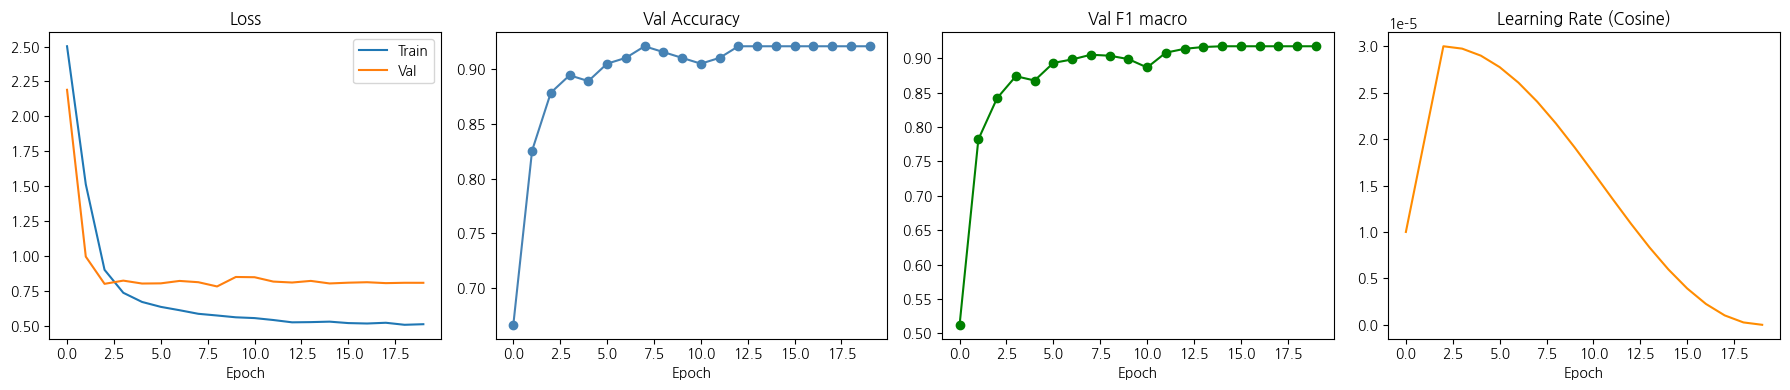

In [ ]:
# 학습 곡선
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].plot(history['val_acc'], color='steelblue', marker='o')
axes[1].set_title('Val Accuracy'); axes[1].set_xlabel('Epoch')
axes[2].plot(history['val_f1'], color='green', marker='o')
axes[2].set_title('Val F1 macro'); axes[2].set_xlabel('Epoch')
axes[3].plot(history['lr'], color='darkorange')
axes[3].set_title('Learning Rate (Cosine)'); axes[3].set_xlabel('Epoch')
plt.tight_layout(); plt.show()

## 4. 최종 평가

Test Accuracy:   0.9263
Test F1 macro:   0.9009
Test F1 weighted:0.9277

              precision    recall  f1-score   support

        ROTC       1.00      1.00      1.00         7
    공모전/경진대회       0.88      0.88      0.88         8
       교육/특강       0.70      0.78      0.74         9
        국제교류       0.80      0.80      0.80         5
     기숙사/생활관       1.00      1.00      1.00         3
     봉사/서포터즈       1.00      0.88      0.93        16
         비교과       0.76      0.90      0.83        21
     장학금/학자금       0.96      0.96      0.96        26
          창업       1.00      0.75      0.86         4
       취업/채용       0.97      0.98      0.98        63
        학사행정       1.00      0.89      0.94        28

    accuracy                           0.93       190
   macro avg       0.92      0.89      0.90       190
weighted avg       0.93      0.93      0.93       190



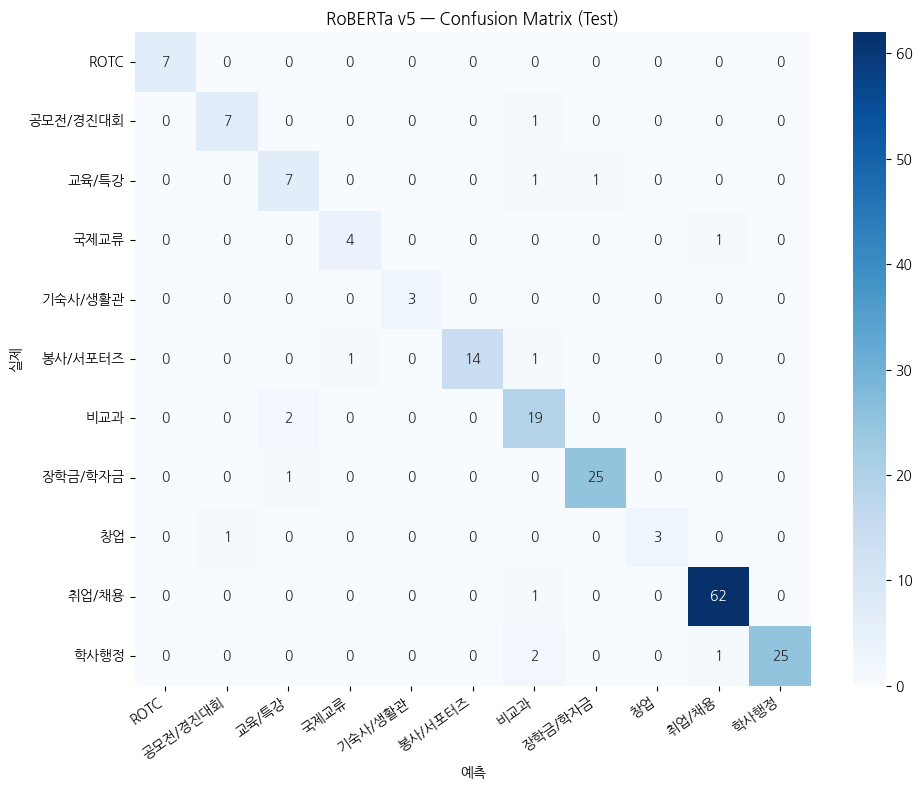

In [ ]:
test_acc, test_f1, _, y_true, y_pred = evaluate(model, test_loader)
test_f1_w = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f'Test Accuracy:   {test_acc:.4f}')
print(f'Test F1 macro:   {test_f1:.4f}')
print(f'Test F1 weighted:{test_f1_w:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('RoBERTa v5 — Confusion Matrix (Test)')
ax.set_ylabel('실제'); ax.set_xlabel('예측')
plt.xticks(rotation=35, ha='right')
plt.tight_layout(); plt.show()

## 5. 추론 함수

In [ ]:
THRESHOLD = 0.60  # 이 값 미만이면 '기타'로 후처리

def predict(title: str, body: str = '', threshold: float = THRESHOLD) -> dict:
    """RoBERTa v5 단일 추론"""
    model.eval()
    enc = tokenizer(
        title, body,
        max_length=MAX_LEN, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    with torch.no_grad():
        logits = model(
            input_ids=enc['input_ids'].to(DEVICE),
            attention_mask=enc['attention_mask'].to(DEVICE)
        ).logits
    probs      = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    pred       = probs.argmax()
    confidence = float(probs[pred])
    category   = '기타' if confidence < threshold else le.classes_[pred]
    return {
        'category':   category,
        'confidence': f'{confidence*100:.1f}%',
        'all_probs':  {le.classes_[i]: f'{p*100:.1f}%' for i, p in enumerate(probs)},
    }

# ── 샘플 테스트 ──────────────────────────────────────────────────────
test_titles = [
    ('2026학년도 1학기 수강신청 안내', ''),
    ('외국인 유학생 한국어 멘토링 봉사', ''),
    ('국가근로장학금 신청 기간 공지', ''),
    ('하반기 대기업 채용 설명회', ''),
    ('봉사활동 서포터즈 3기 모집', ''),
    ('2026 직무역량 강화 특강 안내', '')
]

print(f'{"제목":<35} {"카테고리":>12} {"신뢰도":>8}')
print('-' * 58)
for title, body in test_titles:
    r = predict(title, body)
    print(f'{title:<35} {r["category"]:>12} {r["confidence"]:>8}')

제목                                          카테고리      신뢰도
----------------------------------------------------------
2026학년도 1학기 수강신청 안내                         학사행정    88.1%
외국인 유학생 한국어 멘토링 봉사                          국제교류    96.5%
국가근로장학금 신청 기간 공지                         장학금/학자금    90.0%
하반기 대기업 채용 설명회                             취업/채용    75.6%
봉사활동 서포터즈 3기 모집                          봉사/서포터즈    94.2%
2026 직무역량 강화 특강 안내                         교육/특강    96.0%


## 6. 모델 저장

In [ ]:
import os
SAVE_DIR = '/content/drive/MyDrive/robert'
os.makedirs(SAVE_DIR, exist_ok=True)

# RoBERTa 저장
MODEL_SAVE_PATH = f'{SAVE_DIR}/roberta_v5_classifier'
model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)
with open(f'{MODEL_SAVE_PATH}/label_encoder.json', 'w', encoding='utf-8') as f:
    json.dump({'classes': le.classes_.tolist()}, f, ensure_ascii=False)
print(f'모델 저장 완료: {MODEL_SAVE_PATH}')

# 설정값 저장
with open(f'{SAVE_DIR}/roberta_v5_config.json', 'w') as f:
    json.dump({
        'model':              MODEL_NAME,
        'max_len':            MAX_LEN,
        'threshold':          THRESHOLD,
        'test_accuracy':      round(test_acc, 4),
        'test_f1_macro':      round(test_f1,  4),
        'test_f1_weighted':   round(test_f1_w, 4),
    }, f, indent=2)
print(f'설정 저장 완료: {SAVE_DIR}/roberta_v5_config.json')
print(f'  Test Accuracy: {test_acc:.4f} | F1 macro: {test_f1:.4f} | F1 weighted: {test_f1_w:.4f}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

모델 저장 완료: /content/drive/MyDrive/robert/roberta_v5_classifier
설정 저장 완료: /content/drive/MyDrive/robert/roberta_v5_config.json
  Test Accuracy: 0.9263 | F1 macro: 0.9009 | F1 weighted: 0.9277
